# Analyzing Online Sports Revenue

An analysis of ~3,100 sportswear products (Adidas and Nike): how listing-price tiers relate
to revenue, and whether product description length relates to customer ratings and review volume.

*Based on a DataCamp guided project; code tidied and visualizations added. Data provided with the project.*

In [1]:
# Importing libraries
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Loading the data
brands = pd.read_csv("brands.csv")
finance = pd.read_csv("finance.csv")
info = pd.read_csv("info.csv")
reviews = pd.read_csv("reviews.csv")

# Merge the four tables on product_id and drop rows with missing values
merged_df = info.merge(finance, on="product_id")
merged_df = merged_df.merge(reviews, on="product_id")
merged_df = merged_df.merge(brands, on="product_id")
merged_df.dropna(inplace=True)
print(f"Products after merging and dropping missing values: {len(merged_df)}")

Products after merging and dropping missing values: 3117


## Revenue by price tier and brand

In [2]:
# Cut the listing price into quartile-based tiers
merged_df['price_label'] = pd.qcut(merged_df['listing_price'], q=4,
                                   labels=['Budget', 'Average', 'Expensive', 'Elite'])

# Product volume and average revenue per brand and price tier
adidas_vs_nike = (merged_df
                  .groupby(['brand', 'price_label'], observed=True, as_index=False)
                  .agg(num_products=('price_label', 'count'),
                       mean_revenue=('revenue', 'mean'))
                  .round(2))
adidas_vs_nike

,brand,price_label,num_products,mean_revenue
0,Adidas,Budget,574,2015.68
1,Adidas,Average,655,3035.30
2,Adidas,Expensive,759,4621.56
3,Adidas,Elite,587,8302.78
4,Nike,Budget,357,1596.33
5,Nike,Average,8,675.59
6,Nike,Expensive,47,500.56
7,Nike,Elite,130,1367.45


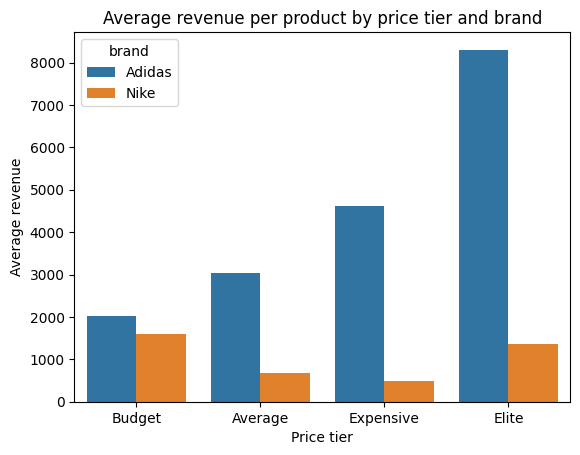

In [3]:
# Visualize average revenue per price tier for each brand
fig, ax = plt.subplots()
sns.barplot(data=adidas_vs_nike, x="price_label", y="mean_revenue", hue="brand", ax=ax)
ax.set_title("Average revenue per product by price tier and brand")
ax.set_xlabel("Price tier")
ax.set_ylabel("Average revenue")
plt.show()

## Description length vs. ratings and reviews

In [4]:
# Bin the product description length into 100-character intervals
merged_df['description_str_count'] = merged_df['description'].str.len()
limits = list(range(0, 800, 100))
labels = list(map(str, limits[1:]))
merged_df['description_length'] = pd.cut(merged_df['description_str_count'], bins=limits,
                                         labels=labels, include_lowest=True)

# Average rating and total reviews per description-length bin
description_lengths = (merged_df
                       .groupby("description_length", observed=True, as_index=False)
                       .agg(mean_rating=("rating", "mean"),
                            total_reviews=("reviews", "sum"))
                       .round(2))
description_lengths

,description_length,mean_rating,total_reviews
0,100,2.26,36.0
1,200,3.19,17719.0
2,300,3.28,76115.0
3,400,3.29,28994.0
4,500,3.35,4984.0
5,600,3.12,852.0
6,700,3.65,818.0


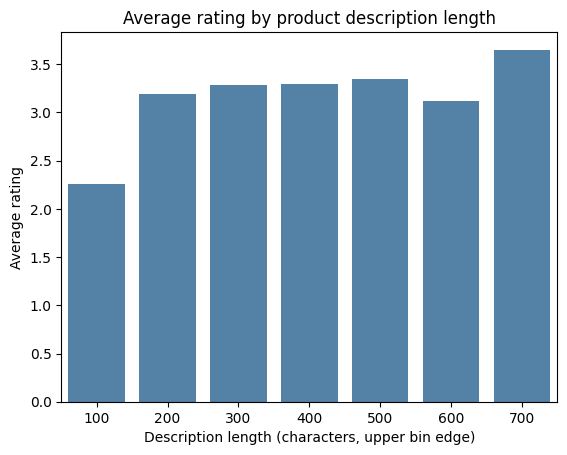

In [5]:
# Visualize mean rating by description length
fig, ax = plt.subplots()
sns.barplot(data=description_lengths, x="description_length", y="mean_rating", ax=ax, color="steelblue")
ax.set_title("Average rating by product description length")
ax.set_xlabel("Description length (characters, upper bin edge)")
ax.set_ylabel("Average rating")
plt.show()

### Key observations

- Adidas products dominate the catalogue in every price tier, and their average revenue rises steeply with price: Elite-tier Adidas products average roughly four times the revenue of Budget-tier ones.
- Nike's products in this dataset cluster in the Budget tier; its mid- and upper-tier segments are thinly represented and generate comparatively low average revenue.
- Ratings are broadly flat (≈3.1-3.4) across description lengths of 200-600 characters, so longer descriptions alone show no clear link to better ratings in this data.